# Масштабирование данных. Стохастический градиентный спуск

Итерационный метод **градиентного спуска** позволяет найти минимум функции потерь, применяется почти в каждой модели машинного обучения. Важная особенность метода - он требует, чтобы значения всех признаков находились в одном масштабе.

## 1. Масштабирование данных

К признаку Прогулы добавим пару новых.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],     # для умножения на intercept
              [10, 5, 3, 2, 0, 9, 1, 0, 8, 2],    # количество прогулов
              [150, 160, 170, 175, 180, 130, 200, 230, 160, 180], # балл ЕГЭ
              [1000, 1500, 2000, 2000, 2500, 1000, 3000, 3500, 1500, 2000] # баллы за предыдущие экзамены
             ]).T
y = [45, 55, 50, 55, 65, 35, 75, 80, 50, 60]      # балл на экзамене

In [3]:
# веса по МНК
w = np.linalg.inv(X.T @ X) @ X.T @ y
w

array([-6.74657969e+00, -1.93669569e-01,  3.17384572e-01,  4.72751732e-03])

In [4]:
X_1 = [1, 1, 100, 1000]
X_2 = [1, 2, 100, 1000]
print(f'Прогноз для 1го студента - {X_1 @ w:.0f}')
print(f'Прогноз для 2го студента - {X_2 @ w:.0f}')
print(X_2 @ w - X_1 @ w) # вес

Прогноз для 1го студента - 30
Прогноз для 2го студента - 29
-0.19366956874911168


Обучим линейную регрессию с использованием градиентного спуска.

In [5]:
from matplotlib import widgets
from sklearn.utils.extmath import weighted_mode

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

# Метод градиентного спуска
def GD(X, y, iterations, eta=1e-4):
    np.random.seed(42)
    n = X.shape[0]                   # число наблюдений
    m = X.shape[1]                   # число признаков
    w = np.random.randn(m)           # начальное приближение весов
    error_pre = mse(y, np.dot(X, w)) # начальная ошибка
    print(f'0: weights={w}, MSE={error_pre:.3f}')
    errors = [error_pre]
    weights = [w.copy()]
    for i in range(1, iterations + 1):
        y_pred = np.dot(X, w)
        grad = 2/n * np.dot(X.T, (y_pred - y))
        w -= eta * grad
        error = mse(y, np.dot(X, w))
        errors.append(error)
        weights.append(w.copy())
        if i % (iterations / 10) == 0:
            print(f'{i}: weights={w}, MSE={error:.3f}')
    return weights, errors

In [8]:
_, _ = GD(X, y, iterations=10000, eta=1e-7)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=11020915.452
1000: weights=[ 0.49536683 -0.14851659  0.45011929 -0.00905665], MSE=76.217
2000: weights=[ 0.494872   -0.15463292  0.39558167 -0.00470233], MSE=45.656
3000: weights=[ 0.49451055 -0.15909409  0.35591501 -0.00153529], MSE=29.489
4000: weights=[ 0.49424612 -0.16235136  0.32706478  0.00076816], MSE=20.935
5000: weights=[ 0.49405226 -0.16473297  0.3060819   0.00244349], MSE=16.410
6000: weights=[ 0.49390972 -0.16647766  0.29082135  0.00366194], MSE=14.016
7000: weights=[ 0.49380452 -0.16775908  0.27972294  0.00454809], MSE=12.750
8000: weights=[ 0.49372647 -0.16870352  0.27165188  0.00519254], MSE=12.080
9000: weights=[ 0.49366817 -0.16940287  0.26578277  0.00566119], MSE=11.725
10000: weights=[ 0.49362423 -0.16992393  0.26151524  0.00600197], MSE=11.538


Алгоритм расходится по причине слишком большой ошибки на данных. Поэтому до применения метода градиентного спуска необходимо привести данные к одному масштабу. Разберем два способа масштабирования: нормализация и стандартизация.

### Нормализация

Метод нормализации заключается в приведении признаков к одному масштабу со значениями в диапазоне `[0-1]` по формуле:

$$x_{ij} = \frac{x_{ij} - min_{j} (x_{ij})}{max_{j} (x_{ij})-min_{j} (x_{ij})}.$$

In [16]:
X_norm = X.copy()
X_norm = X_norm.astype(np.float64)
X_norm

array([[1.00e+00, 1.00e+01, 1.50e+02, 1.00e+03],
       [1.00e+00, 5.00e+00, 1.60e+02, 1.50e+03],
       [1.00e+00, 3.00e+00, 1.70e+02, 2.00e+03],
       [1.00e+00, 2.00e+00, 1.75e+02, 2.00e+03],
       [1.00e+00, 0.00e+00, 1.80e+02, 2.50e+03],
       [1.00e+00, 9.00e+00, 1.30e+02, 1.00e+03],
       [1.00e+00, 1.00e+00, 2.00e+02, 3.00e+03],
       [1.00e+00, 0.00e+00, 2.30e+02, 3.50e+03],
       [1.00e+00, 8.00e+00, 1.60e+02, 1.50e+03],
       [1.00e+00, 2.00e+00, 1.80e+02, 2.00e+03]])

In [17]:
X_norm[:, 1] = (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min())
X_norm[:, 1]

array([1. , 0.5, 0.3, 0.2, 0. , 0.9, 0.1, 0. , 0.8, 0.2])

In [18]:
X_norm[:, 2] = (X[:, 2] - X[:, 2].min()) / (X[:, 2].max() - X[:, 2].min())
X_norm[:, 3] = (X[:, 3] - X[:, 3].min()) / (X[:, 3].max() - X[:, 3].min())

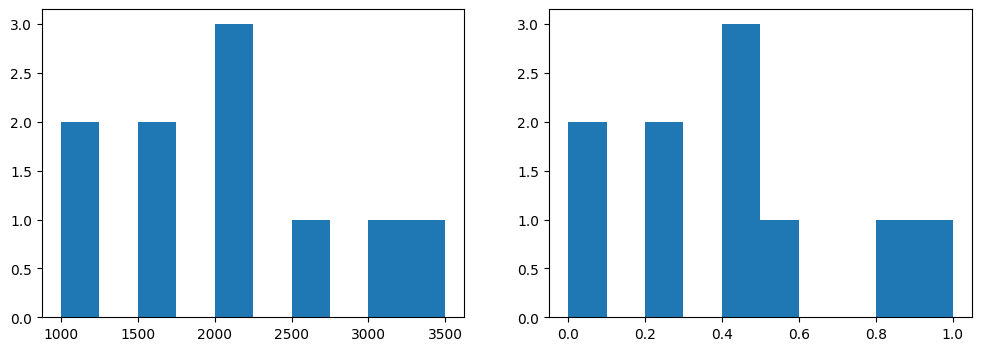

In [ ]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(X[:, 3]);

plt.subplot(1, 2, 2)
plt.hist(X_norm[:, 3]);

### Стандартизация

При стандартизации исходное распределение заменяется на стандартное нормальное распределение (среднее в нуле, стандартное отклонение равно 1) по формуле:

$$x_{ij}=\frac{x_{ij} - \mu_{j}}{\sigma_{j}},$$

где $\mu_j$ - среднее значение $j$-го признака, $\sigma_j$ - стандартное отклонение $j$-го признака.

In [10]:
X_st = X.copy().astype(np.float64)

X_st[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()
X_st[:, 1]

array([ 1.67705098,  0.2795085 , -0.2795085 , -0.55901699, -1.11803399,
        1.39754249, -0.83852549, -1.11803399,  1.11803399, -0.55901699])

In [11]:
X_st[:, 1].mean(), X_st[:, 1].std()

(np.float64(0.0), np.float64(1.0))

In [12]:
X_st[:, 2] = (X[:, 2] - X[:, 2].mean()) / X[:, 2].std()
X_st[:, 3] = (X[:, 3] - X[:, 3].mean()) / X[:, 3].std()

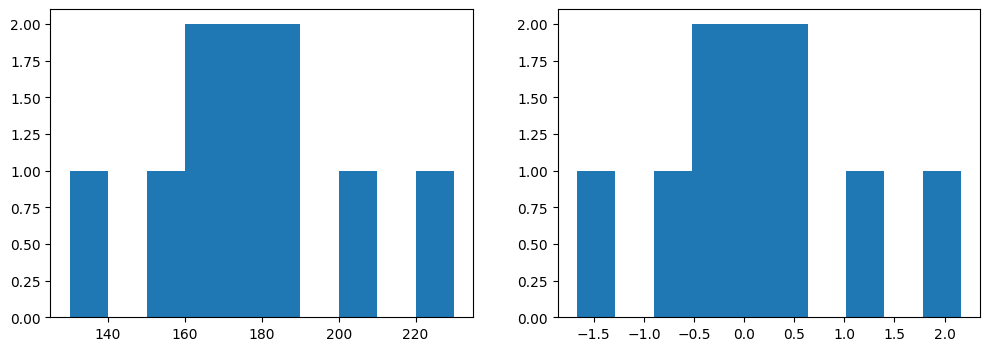

In [ ]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(X[:, 2]);

plt.subplot(1, 2, 2)
plt.hist(X_st[:, 2]);

In [ ]:
w = np.linalg.inv(X_st.T @ X_st) @ X_st.T @ y
mse(y, np.dot(X_st, w)), w

(np.float64(11.117090133766537),
 array([57.        , -0.69289331,  8.27789832,  3.66191917]))

In [14]:
_, _ = GD(X_st, y, iterations=10000, eta=1e-2)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=3307.428
1000: weights=[56.9999999  -0.43511649  7.12661486  5.03433784], MSE=11.207
2000: weights=[57.         -0.49924347  7.63452369  4.47591723], MSE=11.147
3000: weights=[57.         -0.57882275  7.90282516  4.1375785 ], MSE=11.127
4000: weights=[57.         -0.6262538   8.05887031  3.93971095], MSE=11.121
5000: weights=[57.         -0.6539753   8.14998617  3.82414989], MSE=11.118
6000: weights=[57.         -0.67016516  8.20319756  3.75666201], MSE=11.117
7000: weights=[57.         -0.67962006  8.23427303  3.71724905], MSE=11.117
8000: weights=[57.         -0.68514172  8.25242113  3.69423185], MSE=11.117
9000: weights=[57.         -0.68836638  8.26301963  3.6807898 ], MSE=11.117
10000: weights=[57.         -0.69024958  8.26920916  3.67293963], MSE=11.117


In [19]:
_, _ = GD(X_norm, y, iterations=10000, eta=1e-2)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=3248.524
1000: weights=[36.17161031  2.742774   23.32683914 23.88313467], MSE=11.872
2000: weights=[36.75372777  2.00937905 23.34995433 23.1481823 ], MSE=11.729
3000: weights=[37.21433606  1.46808637 23.43014929 22.46509053], MSE=11.631
4000: weights=[37.57366645  1.03568267 23.57318427 21.85470827], MSE=11.560
5000: weights=[37.85483327  0.6875528  23.76109667 21.30412445], MSE=11.506
6000: weights=[38.07566461  0.40492952 23.98011209 20.80309884], MSE=11.463
7000: weights=[38.24988393  0.17334743 24.21978425 20.34359728], MSE=11.428
8000: weights=[ 3.83880566e+01 -1.83493930e-02  2.44722209e+01  1.99192902e+01], MSE=11.398
9000: weights=[38.49831827 -0.17876986 24.73148835 19.52516602], MSE=11.372
10000: weights=[38.58693529 -0.3145624  24.99315319 19.1572329 ], MSE=11.349


### Нормализация из библиотеки sklearn

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_minmax = X.copy().astype(float)
X_minmax[:, 1:] = scaler.fit_transform(X[:, 1:])
X_minmax

array([[1.  , 1.  , 0.2 , 0.  ],
       [1.  , 0.5 , 0.3 , 0.2 ],
       [1.  , 0.3 , 0.4 , 0.4 ],
       [1.  , 0.2 , 0.45, 0.4 ],
       [1.  , 0.  , 0.5 , 0.6 ],
       [1.  , 0.9 , 0.  , 0.  ],
       [1.  , 0.1 , 0.7 , 0.8 ],
       [1.  , 0.  , 1.  , 1.  ],
       [1.  , 0.8 , 0.3 , 0.2 ],
       [1.  , 0.2 , 0.5 , 0.4 ]])

### Стандартизация из библиотеки sklearn

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_ss = X.copy().astype(float)
X_ss[:, 1:] = scaler.fit_transform(X[:, 1:])
X_ss

array([[ 1.        ,  1.67705098, -0.90101825, -1.29099445],
       [ 1.        ,  0.2795085 , -0.51760623, -0.64549722],
       [ 1.        , -0.2795085 , -0.13419421,  0.        ],
       [ 1.        , -0.55901699,  0.0575118 ,  0.        ],
       [ 1.        , -1.11803399,  0.24921781,  0.64549722],
       [ 1.        ,  1.39754249, -1.66784229, -1.29099445],
       [ 1.        , -0.83852549,  1.01604185,  1.29099445],
       [ 1.        , -1.11803399,  2.16627792,  1.93649167],
       [ 1.        ,  1.11803399, -0.51760623, -0.64549722],
       [ 1.        , -0.55901699,  0.24921781,  0.        ]])

## 2. Стохастический градиентный спуск и mini-batch градиентный спуск

Можно выделить три модификации градиентного спуска:

1. **Градиентный спуск** (ГС/GD): рассматривали выше. Градиент считаем на всех примерах обучения.

2. **Стохастический градиентный спуск** (СГС/SGD): на каждом шаге итерации стохастический градиентный спуск вычисляет градиент для одного случайного объекта.

3. **Мini-batch градиентный спуск**: алгоритм будет отбирать небольшой набор данных (batch) и по ним вычислять градиент. Этот вариант подходит для очень больших наборов данных.



In [21]:
# SGD - стохастический градиентный спуск
def SGD(X, y, iterations, eta=1e-4):
    np.random.seed(42)
    n = X.shape[0]                   # число наблюдений
    m = X.shape[1]                   # число признаков
    w = np.random.randn(m)           # начальное приближение весов
    error_pre = mse(y, np.dot(X, w)) # начальная ошибка
    print(f'0: weights={w}, MSE={error_pre:.3f}')
    errors =[error_pre]
    weights = [w.copy()]
    for i in range(1, iterations + 1):
        # генерируем случайный индекс объекта выборки
        ind = np.random.randint(n)
        y_pred = np.dot(X[ind], w)
        grad = 2 * np.dot(X[ind].T, (y_pred - y[ind]))
        w -= eta * grad
        weights.append(w.copy())
        error = mse(y, np.dot(X, w))
        errors.append(error)
        if i % (iterations / 10) == 0:
            print(f'{i}: weights={w}, MSE={error:.3f}')
    return weights, errors

In [20]:
# mini-batch градиентный спуск
def mbGD(X, y, iterations, batch_size=3, eta=1e-4):
    np.random.seed(42)
    n = X.shape[0]                   # число наблюдений
    m = X.shape[1]                   # число признаков
    w = np.random.randn(m)           # начальное приближение весов
    n_batch = n // batch_size             # число батчей
    if n % batch_size != 0:
        n_batch += 1
    print('Количество батчей - ', n_batch)
    error_pre = mse(y, np.dot(X, w)) # начальная ошибка
    print(f'0: weights={w}, MSE={error_pre:.3f}')
    for i in range(1, iterations + 1):
        for b in range(n_batch):
            start_ = batch_size * b
            end_ = batch_size * (b + 1)
            X_batch = X[start_ : end_, :]
            y_batch = y[start_ : end_]
            y_pred = np.dot(X_batch, w)
            grad = 2/len(y_batch) * np.dot(X_batch.T, (y_pred - y_batch))
            w -= eta * grad
        error = mse(y, np.dot(X, w))
        if i % (iterations / 10) == 0:
            print(f'{i}: weights={w}, MSE={error:.3f}')
    return w

In [ ]:
w = GD(X_st, y, iterations=1000, eta=1e-3)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=3307.428
100: weights=[10.74828585 -1.45518343  2.22851731  3.06386088], MSE=2186.439
200: weights=[19.13988214 -2.16091354  3.1701544   3.95421127], MSE=1458.337
300: weights=[26.0089643  -2.51877843  3.74485064  4.47190836], MSE=977.967
400: weights=[31.63176693 -2.67936444  4.10841249  4.77592307], MSE=658.513
500: weights=[36.23440651 -2.7287607   4.35002421  4.95722504], MSE=445.221
600: weights=[40.00197449 -2.71615836  4.52075232  5.06787807], MSE=302.523
700: weights=[43.08598058 -2.66964069  4.64985371  5.1376864 ], MSE=206.951
800: weights=[45.61044558 -2.6052169   4.75410602  5.18371837], MSE=142.901
900: weights=[47.67688883 -2.53199048  4.84314571  5.21575523], MSE=99.956
1000: weights=[49.36841068 -2.45511608  4.92252227  5.23940846], MSE=71.149


In [ ]:
w = SGD(X_st, y, iterations=1000, eta=1e-3)

0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=3307.428
100: weights=[11.0191683  -2.18947016  3.68054238  4.32631763], MSE=2133.677
200: weights=[19.38182803 -1.60284657  3.64847758  4.28904836], MSE=1437.349
300: weights=[26.06003524 -1.23984054  3.85591835  4.33509582], MSE=979.618
400: weights=[31.73712098 -1.81408206  4.55292814  4.91134587], MSE=652.624
500: weights=[36.3648743  -2.25462277  4.98062864  5.15700317], MSE=438.585
600: weights=[40.03655535 -2.13682952  4.70467081  4.95819432], MSE=301.262
700: weights=[43.17146563 -1.93844363  4.53584996  4.76291547], MSE=205.891
800: weights=[45.68694163 -2.09082711  4.88056322  4.99050384], MSE=141.096
900: weights=[47.6489305  -1.9605131   4.88533693  4.92627389], MSE=100.731
1000: weights=[49.25874484 -2.13078509  5.2697995   5.25206712], MSE=72.359


In [25]:
w = mbGD(X_st, y, iterations=1000, batch_size=10, eta=1e-3)

Количество батчей -  1
0: weights=[ 0.49671415 -0.1382643   0.64768854  1.52302986], MSE=3307.428
100: weights=[10.74828585 -1.45518343  2.22851731  3.06386088], MSE=2186.439
200: weights=[19.13988214 -2.16091354  3.1701544   3.95421127], MSE=1458.337
300: weights=[26.0089643  -2.51877843  3.74485064  4.47190836], MSE=977.967
400: weights=[31.63176693 -2.67936444  4.10841249  4.77592307], MSE=658.513
500: weights=[36.23440651 -2.7287607   4.35002421  4.95722504], MSE=445.221
600: weights=[40.00197449 -2.71615836  4.52075232  5.06787807], MSE=302.523
700: weights=[43.08598058 -2.66964069  4.64985371  5.1376864 ], MSE=206.951
800: weights=[45.61044558 -2.6052169   4.75410602  5.18371837], MSE=142.901
900: weights=[47.67688883 -2.53199048  4.84314571  5.21575523], MSE=99.956
1000: weights=[49.36841068 -2.45511608  4.92252227  5.23940846], MSE=71.149


### SGD Линейная регрессия (Stochastic Gradient Descent - стохастический градиентный спуск) из библиотеки sklearn

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
SGDRegressor().get_params()

{'alpha': 0.0001,
 'average': False,
 'early_stopping': False,
 'epsilon': 0.1,
 'eta0': 0.01,
 'fit_intercept': True,
 'l1_ratio': 0.15,
 'learning_rate': 'invscaling',
 'loss': 'squared_error',
 'max_iter': 1000,
 'n_iter_no_change': 5,
 'penalty': 'l2',
 'power_t': 0.25,
 'random_state': None,
 'shuffle': True,
 'tol': 0.001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [ ]:
reg = SGDRegressor(loss='squared_error',
                    fit_intercept=False,
                    max_iter=1000,
                    alpha=0, # коэффициент регуляризации
                    tol=None,
                    n_iter_no_change=100,
                    shuffle=False,
                    eta0=1e-3,
                    learning_rate='constant') # eta = eta0
reg.fit(X_st, y) # обучаем модель
reg.coef_

array([56.99455279, -0.95056506,  6.79386812,  4.87144625])

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

y_pred = reg.predict(X_st) # получаем прогнозы
mean_squared_error(y, y_pred)

11.30370685385174

In [ ]:
r2_score(y, y_pred)

0.9319053803984835

In [ ]:
reg.score(X_st, y)

0.9319053803984835

### Источники

[MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

[Linear model with Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)

[Формулы, используемые методом Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html#sgd-mathematical-formulation)

## Задания

1. Сгенерировать датасет при помощи `sklearn.datasets.make_regression` и обучить линейную модель при помощи градиентного спуска,  стохастического градиентного спуска и mini-batch градиентного спуска. (3 балла)

2. Добавить в функции `GD()`, `SGD()` и `mbGD()` возможность сбора значений ошибки. Построить зависимости среднеквадратичной ошибки (MSE) от числа итераций для всех методов на одном графике. (5 баллов)


3. Сделать выводы о разнице скорости сходимости каждого из методов. (1 балл)

4. Построить графики изменения весов для трех методов. (3 балла)


In [ ]:
# Пример генерации данных для задачи регрессии
from sklearn.datasets import make_regression

X1, y1, coef = make_regression(n_samples=1000,
                             n_features=2,
                             n_informative=2,
                             n_targets=1,
                             noise=5,
                             bias=0, # intersept=0
                             coef=True,
                             random_state=42)
coef # реальные веса

array([40.71064891,  6.60098441])

In [ ]:
X1

array([[-0.16711808,  0.14671369],
       [-0.02090159,  0.11732738],
       [ 0.15041891,  0.364961  ],
       ...,
       [ 0.30263547, -0.75427585],
       [ 0.38193545,  0.43004165],
       [ 0.07736831, -0.8612842 ]])

In [ ]:
# код